In [16]:
%load_ext autoreload
%autoreload 2
import torch 
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.manifold import Isomap, SpectralEmbedding
from sklearn.datasets import make_swiss_roll
from finsler_embedding.experiment_run import *
from finsler_embedding.disbm import *
from finsler_embedding.utils import *
from torchvision.ops import MLP



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
N = 2000
noise = 0.1
beta = 0.9
m = 2
eps_scale = 1.0

In [18]:
X, t = make_swiss_roll(n_samples=N, noise=noise)
X = torch.from_numpy(X).float()

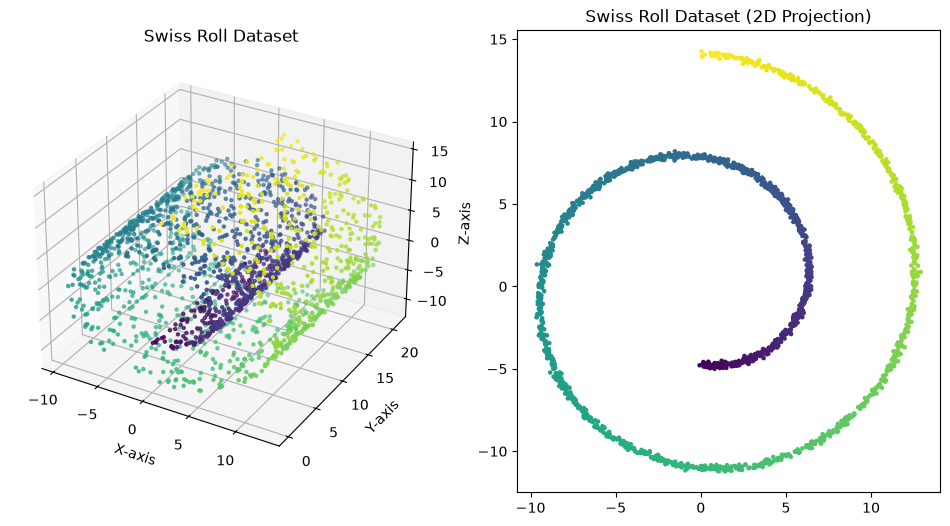

In [19]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(121, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap=plt.cm.viridis, s=5)
ax.set_title("Swiss Roll Dataset")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")

ax = fig.add_subplot(122)
ax.scatter(X[:, 0], X[:, 2], c=t, cmap=plt.cm.viridis, s=5)
ax.set_title("Swiss Roll Dataset (2D Projection)")
plt.show()

In [20]:
base_cometric = IdentityCoMetric()
base_cometric = CentroidsCometric(centroids=X, cometric_centroids=base_cometric(X))
omega_true = get_omega("swiss_roll", cometric=base_cometric,dim=3)
# omega_true = get_omega("swiss_roll_normal", cometric=base_cometric,dim=3)

randers_metric = RandersMetrics(
    base_cometric=base_cometric,
    omega=omega_true,
    beta=beta,
)

omega_x = omega_true(X)


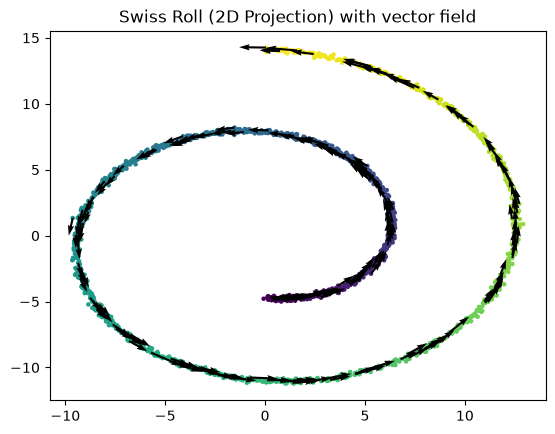

In [21]:

skip=10
plt.scatter(X.detach()[:, 0], X.detach()[:, 2], c=t, cmap=plt.cm.viridis, s=5)
plt.quiver(X.detach()[::skip, 0], X.detach()[::skip, 2], omega_x.detach()[::skip, 0], omega_x.detach()[::skip, 2], 
           angles='xy', scale_units='xy')
plt.title("Swiss Roll (2D Projection) with vector field")
plt.show()

In [22]:
edges = get_knn_graph(X, n_neighbors=10,device="cpu")
LOGGER.info(f"Found {edges.shape[0]} edges in the KNN graph.")
dst_edges = construct_distance_matrix(X, edges, randers_metric,use_approx=True)

[2026-09-21 14:07:21] - INFO - Found 23072 edges in the KNN graph.


Computing Randers distances: 100%|██████████| 231/231 [00:03<00:00, 67.36it/s]


In [23]:
X_low = Isomap(n_components=m, n_neighbors=10).fit_transform(X)
X_low = torch.from_numpy(X_low).float()
bounds = get_bounds(X_low,margin=0.1)

In [24]:
epsilon = compute_epsilon_empirical(dst_edges, scale=eps_scale)
W, _, _ = gaussian_kernel(edges, dst_edges, epsilon, N, m)
results = randers_approximation(X_low,W, epsilon, m=m)
V = results["V"]
V_normed = V / (results["c_norm_sq"].sqrt() + 1e-12).unsqueeze(1)
unit_V = V / (V.norm(dim=1, keepdim=True) + 1e-12)

In [29]:
# Sort by x coords for display
idx = torch.argsort(X_low[:, 0])
X_low_plt = X_low[idx].clone()
V_plt = V[idx].clone()
unit_V_plt = unit_V[idx].clone()
t_plt = t[idx]

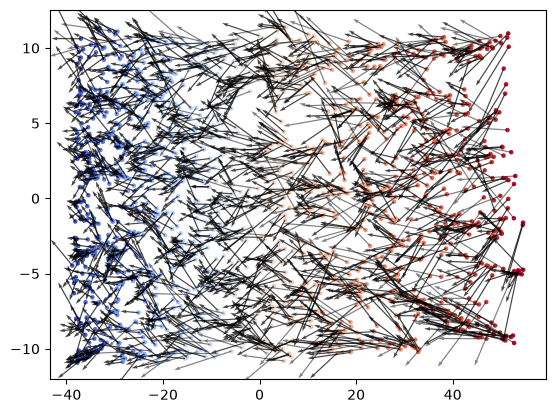

In [31]:
cbar = plt.scatter(
    X_low_plt[:, 0], X_low_plt[:, 1], c=t_plt, cmap="coolwarm",s=5
)
skip=1
plt.quiver(
    X_low_plt[::skip, 0],
    X_low_plt[::skip, 1],
    # unit_V_plt[::skip, 0],
    # unit_V_plt[::skip, 1],
    V_plt[::skip, 0],
    V_plt[::skip, 1],
    color="black",
    scale=.3,
    angles="xy",
    scale_units="xy",
    alpha = results["admissible"][idx][::skip].float().sigmoid()
)

In [32]:
model, loss_list = interpolate_V(X_low, V, dim=m)

  0%|          | 0/500 [00:00<?, ?it/s]

Loss: 0.1966: 100%|██████████| 500/500 [00:01<00:00, 416.91it/s]


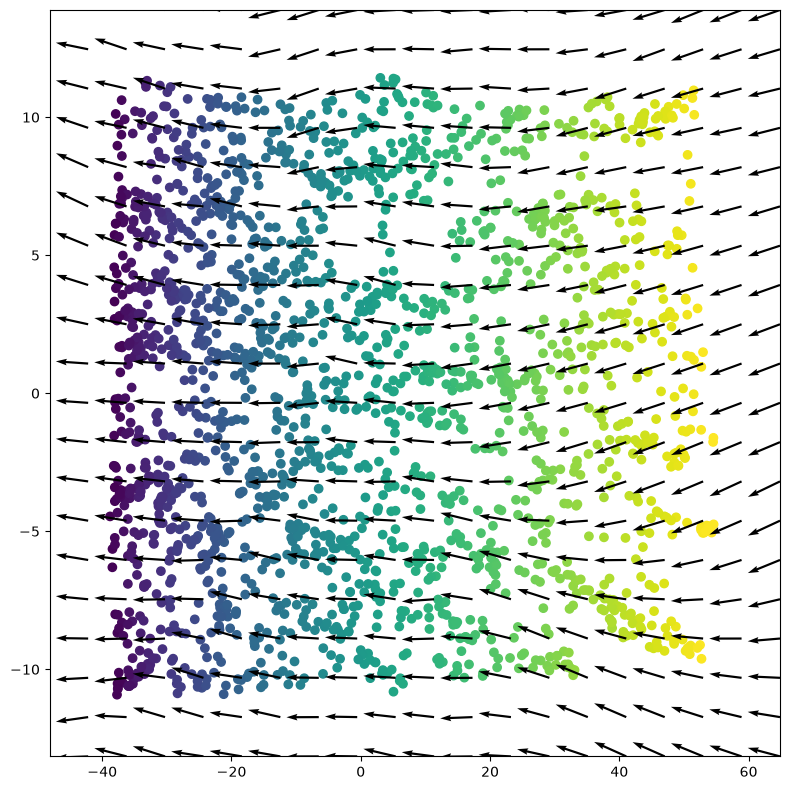

In [33]:
# Grid
x = torch.linspace(bounds[0], bounds[1], 20)
y = torch.linspace(bounds[2], bounds[3], 20)
X, Y = torch.meshgrid(x, y, indexing="ij")
grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1)
# grid_points += 1e-1 * torch.randn_like(grid_points)
V_grid = model(grid_points).detach()
V_grid_unit = V_grid / (V_grid.norm(dim=1, keepdim=True) + 1e-12)

plt.figure(figsize=(8, 8))
plt.scatter(X_low[:, 0], X_low[:, 1], c=t, cmap=plt.cm.viridis)
plt.quiver(
    grid_points[:, 0],
    grid_points[:, 1],
    V_grid_unit[:, 0],
    V_grid_unit[:, 1],
    color="black",
    scale=0.2,
    angles="xy",
    scale_units="xy",
)
plt.xlim(bounds[0], bounds[1])
plt.ylim(bounds[2], bounds[3])
plt.tight_layout()
# plt.axis("equal")
plt.show()